<a href="https://colab.research.google.com/github/SampMark/Deep-Learning/blob/main/Denoising_Autoencoders_Convolucionais_consolidated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Explorando Denoising Autoencoders Convolucionais com Keras e MNIST, como fundamento para Modelos de Difusão**


Os Modelos Probabilísticos de Difusão representam uma classe poderosa de modelos generativos, com destaque crescente na área de aprendizado de máquina profundo, especialmente pela sua capacidade de gerar dados sintéticos de alta qualidade, aqui faremos uma breve introdução, com base no referencial explorado.

Este notebook foca na implementação e experimentação de Denoising Autoencoders Convolucionais (DAEC) usando Keras e o dataset MNIST. Entender DAECs é um passo crucial para compreender o componente de remoção de ruído dos Modelos Probabilísticos de Difusão (MPD).

## **1. Introdução e Conceito**

No artigo de Sohl-Dickstein et al (2015), intitulado "_Deep Unsupervised Learning using Nonequilibrium Thermodynamics_", apresentado na 32ª Conferência Internacional sobre Aprendizado de Máquina (ICML), os autores introduziram uma abordagem inovadora para a modelagem probabilística de dados complexos no contexto de aprendizado profundo não supervisionado, abrindo um promissor campo de pesquisa. Essa modelagem foi inspirado na **termodinâmica fora do equilíbrio**, em que a distribuição inicial se “difunde” para o equilíbrio gaussiano, em seguida, o modelo aprende a “condensar” o ruído de volta à distribuição dos dados.

Os autores enfrentaram o dilema crucial no campo do aprendizado de máquina profundo, a escolha entre a flexibilidade dos modelos (capacidade de descrever estruturas ricas em dados) e sua tratabilidade (facilidade de aprendizado, amostragem, inferência e avaliação analítica ou computacional).

Modelos tratáveis tendem a ser simples e incapazes de capturar a complexidade de _datasets_ do mundo real, enquanto modelos flexíveis frequentemente envolvem constantes de normalização intratáveis, exigindo custosos processos de Monte Carlo.

Por este prisma, os autores propuseram um novo paradigma, inspirado na física estatística de não equilíbrio, que visa alcançar simultaneamente flexibilidade e tratabilidade Assim, os Modelos de Difusão são **probabilísticos generativos** capazes de produzir dados iterativamente, a partir do refinamento de amostras iniciais ruidosas. Portanto, foram inspirados no processo de **difusão na física**, em que partículas se espalham gradualmente de regiões de alta concentração para regiões de baixa concentração.

Em termos computacionais, isso significa que o processo é iniciado com uma amostra altamente ruidosa (ruído gaussiano) e serão aplicadas transformações progressivas até se obter uma amostra coerente e semelhante aos dados reais.

### **Significado Prático**
Esses modelos são particularmente úteis porque:
1. Permitem a **geração de dados sintéticos** que seguem a distribuição dos dados originais.
2. São flexíveis o suficiente para serem aplicados em diferentes contextos, tratamento de imagens, áudio, texto, etc.
3. Produzem resultados de alta qualidade, muitas vezes superiores a outras abordagens generativas, como as _Generative Adversarial Networks_(GAN).

## **2. Mecanismo de Funcionamento**

O funcionamento dos Modelos de Difusão pode ser dividido em dois processos estocásticos complementares:

### **Processo Direto** (_Forward Process_)
  Nessa etapa, o objetivo é gradualmente adicionar ruído aos dados reais.
  - **Método**: a cada passo $t$, uma pequena quantidade de ruído gaussiano é adicionada à amostra original. Isto é feito de forma controlada, a fim de garantir que a amostra inicial seja transformada em ruído puro ao final do processo.
  - **Resultado**: Após $T$ passos, os dados originais são completamente corrompidos por ruído.

  Matematicamente, parte-se de uma amostra real $x_0\sim q(x)$ e aplica-se ruído gaussiano em $T$ passos discretos, de modo que:

    $$
      q(x_t\mid x_{t-1}) = \mathcal{N}\bigl(x_t;\,\sqrt{1-\beta_t}x_{t-1},\,\beta_t I\bigr),
    $$

    onde $\{\beta_t\}$ é uma “agenda de variâncias” que normalmente aumenta com $t$. Após muitos passos, $x_T$ torna-se praticamente ruído puro $\mathcal{N}(0,I)$.

### **Processo Reverso** (_Reverse Process_)
  O objetivo nesta etapa é remover o ruído adicionado no processo direto.
  - **Método**: o modelo é treinado para aprender a "desfazer" o ruído progressivamente. Após receber a amostra ruidosa como entrada, tenta reconstruir a amostra original.
  - **Resultado**: ao final do processo reverso, obtém-se uma amostra gerada que segue a distribuição dos dados reais.
    
  É um modelo neural (parametrizado por $\theta$) que aprende a reverter cada etapa de difusão, estimando:

    $$
      p_\theta(x_{t-1}\mid x_t) = \mathcal{N}\bigl(x_{t-1};\;\mu_\theta(x_t,t),\;\Sigma_\theta(x_t,t)\bigr),
    $$

  de modo que, começando de $x_T\sim\mathcal{N}(0,I)$ e aplicando sucessivamente estas distribuições reversas, obtém-se uma amostra aproximada de $x_0$.

Em suma, o **processo direto** é determinístico e não requer treinamento (é definido matematicamente). E o **processo reverso** é aprendido pelo modelo durante o treinamento e é responsável pela geração de novas amostras.

## **Aplicações**

Devido à sua versatilidade, têm sido amplamente utilizados em várias aplicações, tais como:

1. **Geração de imagens** realistas a partir de ruído aleatório.
  - Exemplo: Gerar rostos humanos sintéticos para datasets de treinamento.

2. **Remoção de Ruído** (_Denoising_) para melhorar a qualidade de imagens corrompidas por ruído.
  - Exemplo: Restaurar imagens capturadas em condições de baixa luminosidade.

3. **Aumento de Dados** (_Data Augmentation) para geração de novas amostras sintéticas de modo a aumentar a diversidade de um _dataset_ de treinamento.
  - Exemplo: Ampliar um dataset de imagens médicas para melhorar a generalização de modelos de diagnóstico.

4. **Outras Aplicações**
  - Síntese de áudio e música.
  - Geração de texto condicional.
  - Modelagem de sistemas físicos e biológicos.


O artigo de SOHL-DICKSTEIN et al. (2015) lançou as bases para o que se tornaria uma das áreas mais ativas e bem-sucedidas na modelagem generativa. A ideia de destruir e restaurar gradualmente a estrutura nos dados provou ser extremamente poderosa, e as melhorias subsequentes em arquiteturas de rede, objetivos de treinamento e técnicas de amostragem transformaram os modelos de difusão em ferramentas de ponta para geração de dados de alta fidelidade. A clareza conceitual e a demonstração inicial de viabilidade em diversos _datasets_ tornam este um trabalho fundamental e altamente influente.

A implementação de um _Denoising Diffusion Probabilistic Models_ (DDPM) completo é complexo. Neste notebook, o foco será no "coração" do processo reverso, isto é, treinar uma rede para remover ruído de uma imagem; o que é análogo a um único passo de denoising no processo reverso ou a um Denoising Autoencoder Convolucional como Aproximação.

In [1]:
# Verifica se há GPU disponível e apresenta informações
import os
import subprocess

def verificar_gpu():
    try:
        resultado = subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT)
        print(resultado.decode('utf-8'))
    except Exception:
        print('Não há GPU disponível ou nvidia-smi falhou.')

verificar_gpu()

Fri May  9 21:14:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   61C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install tensorflow

In [3]:
# Importações principais
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# ---------------------------
# @title 1. Carregamento e pré-processamento dos dados
# ---------------------------
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Normaliza pixels para o intervalo [0,1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

print(f"Formato do treinamento: {x_train.shape}")
print(f"Formato do teste:      {x_test.shape}")

Formato do treinamento: (60000, 28, 28)
Formato do teste:      (10000, 28, 28)


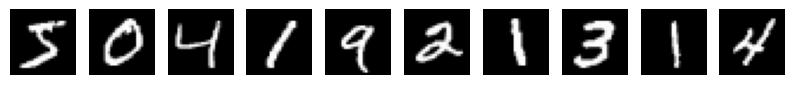

In [6]:
# Visualização de algumas amostras originais
def mostrar_amostras(originais, n=10):
    plt.figure(figsize=(10, 2))
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        plt.imshow(originais[i], cmap='gray')
        ax.axis('off')
    plt.show()

mostrar_amostras(x_train)

In [7]:
# Ajusta canal de cor (para convolução)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

In [8]:
# ---------------------------
# @title 2. Adição de ruído Gaussiano (denoising)
# ---------------------------
noise_factor = 0.5  # Fator que controla a intensidade do ruído

def adicionar_ruido(x, fator):
    """
    Recebe um tensor de imagens x e adiciona ruído gaussiano controlado.
    Retorna as imagens ruidosas no mesmo intervalo [0,1].
    """
    ruido = np.random.normal(loc=0.0, scale=1.0, size=x.shape)
    x_noisy = x + fator * ruido
    x_noisy = np.clip(x_noisy, 0.0, 1.0)
    return x_noisy

x_train_noisy = adicionar_ruido(x_train, noise_factor)
x_test_noisy  = adicionar_ruido(x_test,  noise_factor)

print(f"Formato com ruído (treino): {x_train_noisy.shape}")
print(f"Formato com ruído (teste):  {x_test_noisy.shape}")

Formato com ruído (treino): (60000, 28, 28, 1)
Formato com ruído (teste):  (10000, 28, 28, 1)


In [9]:
# ---------------------------
# @title 3. Definição da arquitetura do Autoencoder Convolucional
# ---------------------------

def construir_autoencoder():
    """
    Constrói um modelo de autoencoder convolucional simples:
    - Encoder: duas camadas Conv2D + Flatten + Dense
    - Decoder: Dense + Reshape + duas camadas Conv2DTranspose + Conv2D de saída
    Retorna o modelo compilado.
    """
    entrada = Input(shape=(28, 28, 1), name='entrada')

    # Encoder
    x = Conv2D(16, (3, 3), activation='relu', padding='same', name='enc_conv1')(entrada)
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = Flatten(name='enc_flat')(x)
    x = Dense(64, activation='relu', name='enc_dense')(x)

    # Decoder
    x = Dense(28 * 28 * 32, activation='relu', name='dec_dense')(x)
    x = Reshape((28, 28, 32), name='dec_reshape')(x)
    x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same', name='dec_deconv1')(x)
    x = Conv2DTranspose(16, (3, 3), activation='relu', padding='same', name='dec_deconv2')(x)
    saida = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='dec_output')(x)

    modelo = Model(inputs=entrada, outputs=saida, name='autoencoder_denoising')
    modelo.compile(optimizer='adam', loss='mean_squared_error')
    return modelo

# Cria e exibe o resumo do modelo
autoencoder = construir_autoencoder()
autoencoder.summary()

Model: "autoencoder_denoising"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_flat (Flatten)              │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense (Dense)               │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 25088)          │     1,630,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv2DTranspose)   │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv2DTranspose)   │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (Conv2D)             │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,255,233 (12.42 MB)

 Trainable params: 3,255,233 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ---------------------------
# @title 4. Preparação do dataset para treinamento
# ---------------------------
batch_size = 64

dataset_treino = (
    tf.data.Dataset.from_tensor_slices((x_train_noisy, x_train))
    .cache()
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

dataset_validacao = (
    tf.data.Dataset.from_tensor_slices((x_test_noisy, x_test))
    .cache()
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Callbacks para parada antecipada e controle de learning rate
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitora a perda na validação
    patience=5,          # Paciência de 5 épocas sem melhora
    restore_best_weights=True  # Restaura pesos do melhor epoch
)

In [11]:
# ---------------------------
# @title 5. Treinamento
# ---------------------------
epocas = 15
autoencoder.fit(
    dataset_treino,
    epochs=epocas,
    shuffle=True,
    validation_data=dataset_validacao,
    callbacks=[early_stopping]
)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0556 - val_loss: 0.0167
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0136 - val_loss: 0.0137
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0115 - val_loss: 0.0127
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0105 - val_loss: 0.0130
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0098 - val_loss: 0.0131
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0092 - val_loss: 0.0126
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0088 - val_loss: 0.0128
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0084 - val_loss: 0.0133
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0080 - val_loss: 0.0135
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0078 - val_loss: 0.0141
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0077 - val_loss: 0.0140


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


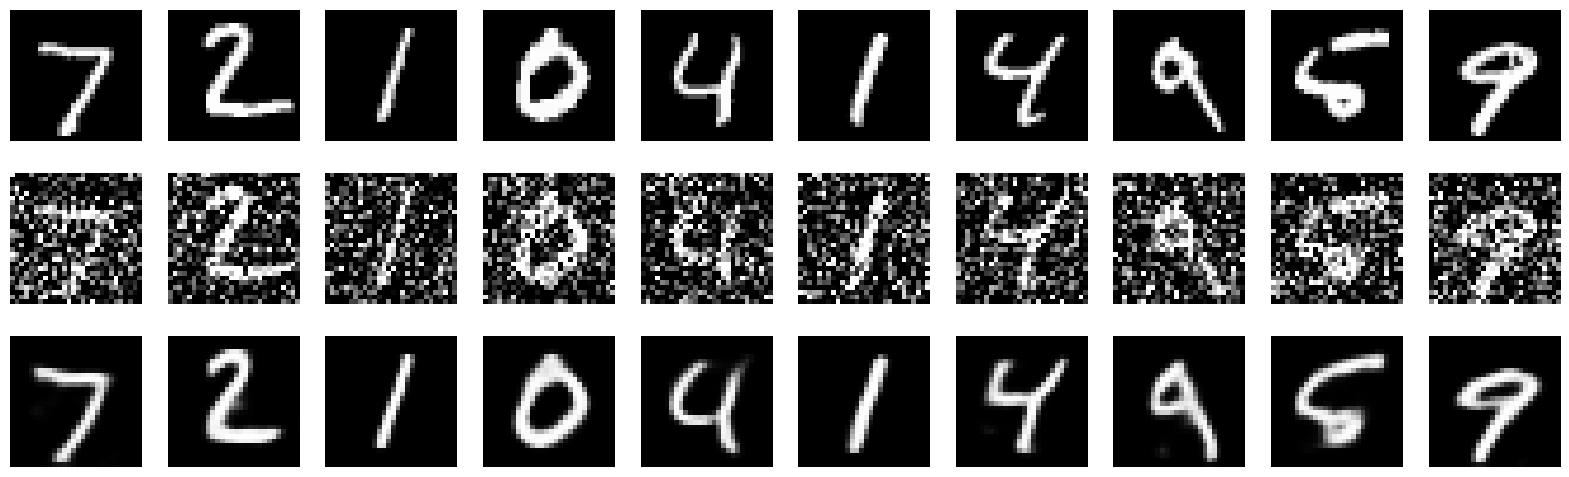

In [12]:
# ---------------------------
# @title 6. Avaliação e visualização dos resultados
# ---------------------------

def visualizar_resultados(modelo, x_noisy, x_original, n=10):
    """
    Gera previsões com o modelo e exibe:
    1) Imagem original
    2) Imagem com ruído
    3) Imagem reconstruída
    """
    denoised = modelo.predict(x_noisy)
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Original
        ax = plt.subplot(3, n, i+1)
        plt.imshow(x_original[i].reshape(28, 28), cmap='gray')
        ax.axis('off')

        # Com ruído
        ax = plt.subplot(3, n, i+1 + n)
        plt.imshow(x_noisy[i].reshape(28, 28), cmap='gray')
        ax.axis('off')

        # Reconstruída
        ax = plt.subplot(3, n, i+1 + 2*n)
        plt.imshow(denoised[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
    plt.show()

visualizar_resultados(autoencoder, x_test_noisy, x_test)

In [14]:
# ---------------------------
# @title 7. Experimentação com alterações nos hiperparâmetros
# ---------------------------
# Exemplo: trocar função de perda para binary_crossentropy e continuar treinamento
for layer in autoencoder.layers[-4:]:
    layer.trainable = True  # Garante que o decoder permaneça treinável

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# Ajuste do noise_factor para observar impacto no desempenho
noise_factor = 0.3
global x_train_noisy, x_test_noisy
x_train_noisy = adicionar_ruido(x_train, noise_factor)
x_test_noisy  = adicionar_ruido(x_test,  noise_factor)

autoencoder.fit(
    x_train_noisy, x_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0757 - val_loss: 0.0774
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0749 - val_loss: 0.0776
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0742 - val_loss: 0.0776
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0734 - val_loss: 0.0778
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0728 - val_loss: 0.0784
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0721 - val_loss: 0.0786
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0768 - val_loss: 0.0764
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0757 - val_loss: 0.0763
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0755 - val_loss: 0.0767
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0751 - val_loss: 0.0761
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0745 - val_loss: 0.0762
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step -

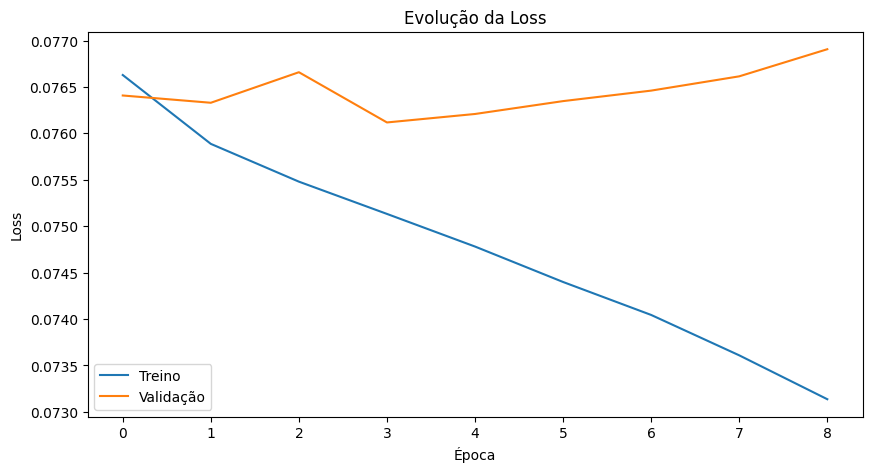

In [15]:
# Exibe métricas de perda durante o treinamento
plt.figure(figsize=(10, 5))
plt.plot(autoencoder.history.history['loss'], label='Treino')
plt.plot(autoencoder.history.history['val_loss'], label='Validação')
plt.title('Evolução da Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [17]:
# ---------------------------
# @title 8. Segunda arquitetura de comparação
# ---------------------------

# Implementação de mais camadas ao modelo para avaliar o desempenho
input_layer = Input(shape=(28, 28, 1))
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_layer)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x) # Added Conv2D layer
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dense(28*28*32, activation='relu')(x)
x = Reshape((28, 28, 32))(x)
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x) #Added Conv2DTranspose layer
x = Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(x)
output_layer = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

diffusion_model2 = Model(input_layer, output_layer)
diffusion_model2.compile(optimizer='adam', loss='mean_squared_error')
diffusion_model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25088)          │     1,630,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 128)    │        36,992 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 16)     │        18,448 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,159,937 (31.13 MB)

 Trainable params: 8,159,937 (31.13 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = diffusion_model2.fit(
    x_train_noisy, x_train,
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
    )

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - loss: 0.0588 - val_loss: 0.0089
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0083 - val_loss: 0.0067
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0065 - val_loss: 0.0061
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0058 - val_loss: 0.0058
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0054 - val_loss: 0.0057
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0050 - val_loss: 0.0057
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0046 - val_loss: 0.0058
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0042 - val_loss: 0.0058
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0039 - val_loss: 0.0060
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0036 - val_loss: 0.0061
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0034 - val_loss: 0.0062
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━

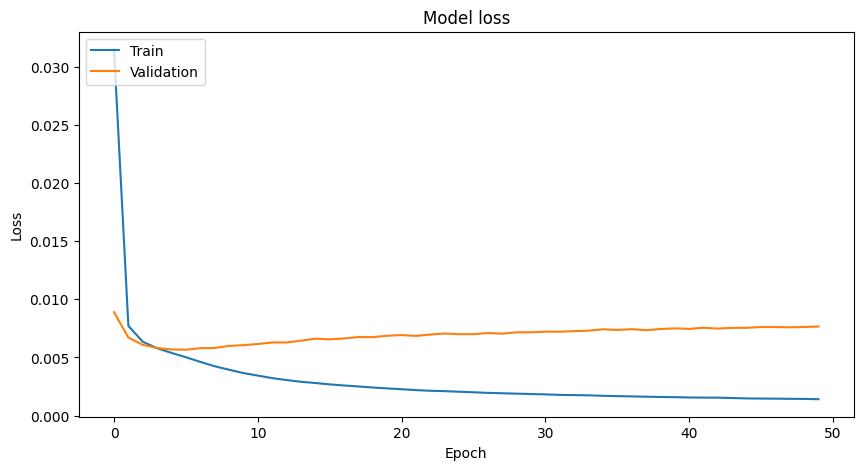

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(diffusion_model2.history.history['loss'])
plt.plot(diffusion_model2.history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

if 'accuracy' in diffusion_model2.history.history:
    plt.figure(figsize=(10, 5))
    plt.plot(diffusion_model2.history.history['accuracy'])
    plt.plot(diffusion_model2.history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

# **Referências**

* HO, Jonathan; JAIN, Ajay; ABBEEL, Pieter. **Denoising diffusion probabilistic models**. Advances in neural information processing systems, v. 33, p. 6840-6851, 2020. Disponível em: https://proceedings.neurips.cc/paper/2020/file/4c5bcfec8584af0d967f1ab10179ca4b-Paper.pdf. Acesso em: 5 de maio de 2025.

* SOHL-DICKSTEIN, Jascha; WEISS, Eric A.; MAHESWARANATHAN, Niru; GANGULI, Surya. **Deep unsupervised learning using nonequilibrium thermodynamics**. In: International Conference on Machine Learning. PMLR, 2015. p. 2256-2265. (JMLR: W&CP volume 37). Disponível em: http://proceedings.mlr.press/v37/sohl-dickstein15.html (ou link do arXiv, se aplicável). Acesso em: 4 de maio de 2025.

* SONG, Jiaming; MENG, Chenlin; ERMON, Stefano. **Denoising Diffusion Implicit Models**. In: International Conference on Learning Representations (ICLR), 2021. Disponível em: https://doi.org/10.48550/arXiv.2010.02502. Acesso em: 9 de maio de 2025.